# Amazon Reviews 2023 — EDA (CRISP-DM §2.2 + §2.3)

Data Understanding phase for the cross-domain recommendation project.
Covers the activities the CRISP-DM User Guide assigns to §2.2 (Describe Data)
and §2.3 (Explore Data):

- **§2.2 Describe Data** — volumetric, attribute types/values, keys.
- **§2.3 Explore Data** — properties of interesting attributes, sub-populations,
  hypotheses for the rest of the project.

The single most important §2.3 output for us is the **pairwise shared-user
overlap** across the five downloaded verticals — this is what locks the final
source→target pair (HW1 §S2 gating check, R1 risk).


## Setup

In [1]:
import json, os, time
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import pyarrow.csv as pacsv
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

DATA_ROOT = Path('/Users/orimood/Desktop/homework/Amazon_CR/data/raw')
REVIEWS_DIR = DATA_ROOT / 'reviews'
META_DIR = DATA_ROOT / 'meta'

VERTICALS = ['Books', 'Movies_and_TV', 'CDs_and_Vinyl', 'Video_Games', 'Toys_and_Games']

def reviews_path(v): return REVIEWS_DIR / f'{v}.csv'
def meta_path(v):    return META_DIR / f'meta_{v}.jsonl'

print('Reviews files:')
for v in VERTICALS:
    p = reviews_path(v)
    print(f'  {v:18s} {p.stat().st_size/1e9:6.2f} GB  exists={p.exists()}')
print('Meta files:')
for v in VERTICALS:
    p = meta_path(v)
    print(f'  {v:18s} {p.stat().st_size/1e9:6.2f} GB  exists={p.exists()}')


Reviews files:
  Books                1.69 GB  exists=True
  Movies_and_TV        1.00 GB  exists=True
  CDs_and_Vinyl        0.28 GB  exists=True
  Video_Games          0.26 GB  exists=True
  Toys_and_Games       0.93 GB  exists=True
Meta files:
  Books               14.70 GB  exists=True
  Movies_and_TV        1.29 GB  exists=True
  CDs_and_Vinyl        0.95 GB  exists=True
  Video_Games          0.44 GB  exists=True
  Toys_and_Games       2.64 GB  exists=True


## §2.2 Describe Data

### 2.2.1 Volumetric — ratings tables

Per vertical, count interactions, distinct users, distinct items. This is the
first thing we don't yet know — the 0-core rating tables ship without summary
statistics.


In [2]:
def load_ratings(path):
    """Load a ratings CSV with appropriate dtypes via pyarrow."""
    tbl = pacsv.read_csv(
        path,
        read_options=pacsv.ReadOptions(use_threads=True),
        convert_options=pacsv.ConvertOptions(
            column_types={
                'user_id': 'string',
                'parent_asin': 'string',
                'rating': 'float32',
                'timestamp': 'int64',
            }
        ),
    )
    return tbl.to_pandas(types_mapper=pd.ArrowDtype)

ratings = {}
t0 = time.time()
for v in VERTICALS:
    t = time.time()
    ratings[v] = load_ratings(reviews_path(v))
    print(f'  loaded {v:18s} rows={len(ratings[v]):>11,d}  in {time.time()-t:5.1f}s')
print(f'total load time: {time.time()-t0:.1f}s')


  loaded Books              rows= 29,139,329  in   0.5s


  loaded Movies_and_TV      rows= 17,158,519  in   0.3s
  loaded CDs_and_Vinyl      rows=  4,772,071  in   0.1s
  loaded Video_Games        rows=  4,555,500  in   0.1s


  loaded Toys_and_Games     rows= 16,052,440  in   0.4s
total load time: 1.4s


In [3]:
volumetric = []
for v in VERTICALS:
    df = ratings[v]
    volumetric.append({
        'vertical': v,
        'interactions': len(df),
        'users': df['user_id'].nunique(),
        'items_in_ratings': df['parent_asin'].nunique(),
        'avg_per_user': len(df) / df['user_id'].nunique(),
        'avg_per_item': len(df) / df['parent_asin'].nunique(),
    })
vol_df = pd.DataFrame(volumetric).set_index('vertical')
vol_df


,interactions,users,items_in_ratings,avg_per_user,avg_per_item
vertical,,,,,
Books,29139329,10297355,4446065,2.829788,6.553959
Movies_and_TV,17158519,6503429,747764,2.638380,22.946436
CDs_and_Vinyl,4772071,1754118,701673,2.720496,6.800990
Video_Games,4555500,2766656,137249,1.646573,33.191499
Toys_and_Games,16052440,8116226,890667,1.977821,18.022942


### 2.2.2 Rating value distribution

Distribution of the integer rating 1–5 per vertical. HW1 §1.4 assumption 4
treats rating ≥4 as a positive interaction; we check what fraction of each
vertical that captures.


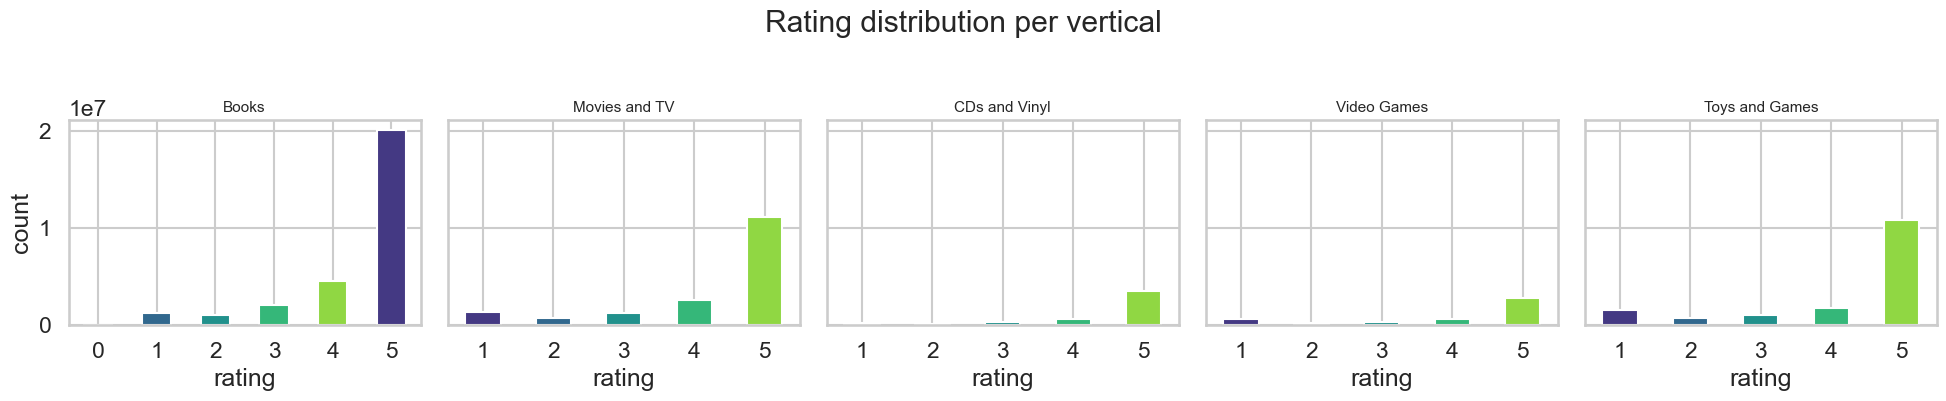

,positive_rate (rating>=4)
Books,0.848963
Movies_and_TV,0.801640
CDs_and_Vinyl,0.873390
Video_Games,0.745014
Toys_and_Games,0.784608


In [4]:
fig, axes = plt.subplots(1, len(VERTICALS), figsize=(20, 4), sharey=True)
for ax, v in zip(axes, VERTICALS):
    s = ratings[v]['rating'].astype('int8').value_counts().sort_index()
    s.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', 5))
    ax.set_title(v.replace('_', ' '), fontsize=11)
    ax.set_xlabel('rating')
    ax.tick_params(axis='x', rotation=0)
axes[0].set_ylabel('count')
plt.suptitle('Rating distribution per vertical', y=1.02)
plt.tight_layout()
plt.show()

# numeric summary: positive (≥4) rate
pos_rate = {v: (ratings[v]['rating'] >= 4).mean() for v in VERTICALS}
pd.Series(pos_rate, name='positive_rate (rating>=4)').to_frame()


### 2.2.3 Timestamp coverage

Timestamps are ms-since-epoch. We need to know the time range per vertical to
decide whether a time-based split is realistic (HW1 §1.3 success criterion 2).


In [5]:
def ts_range(s):
    s = pd.to_datetime(s.astype('int64'), unit='ms')
    return s.min(), s.max()

rows = []
for v in VERTICALS:
    lo, hi = ts_range(ratings[v]['timestamp'])
    rows.append({'vertical': v, 'first': lo, 'last': hi, 'span_years': (hi-lo).days/365.25})
ts_df = pd.DataFrame(rows).set_index('vertical')
ts_df


,first,last,span_years
vertical,,,
Books,1996-06-17 00:08:04,2023-09-14 02:12:29.017,27.241615
Movies_and_TV,1997-08-24 02:46:15,2023-09-12 22:13:12.711,26.050650
CDs_and_Vinyl,1997-09-09 03:13:17,2023-09-09 15:33:39.315,25.998631
Video_Games,1998-11-17 19:58:49,2023-09-12 09:02:35.529,24.815880
Toys_and_Games,1998-10-18 04:01:50,2023-09-13 02:18:35.517,24.900753


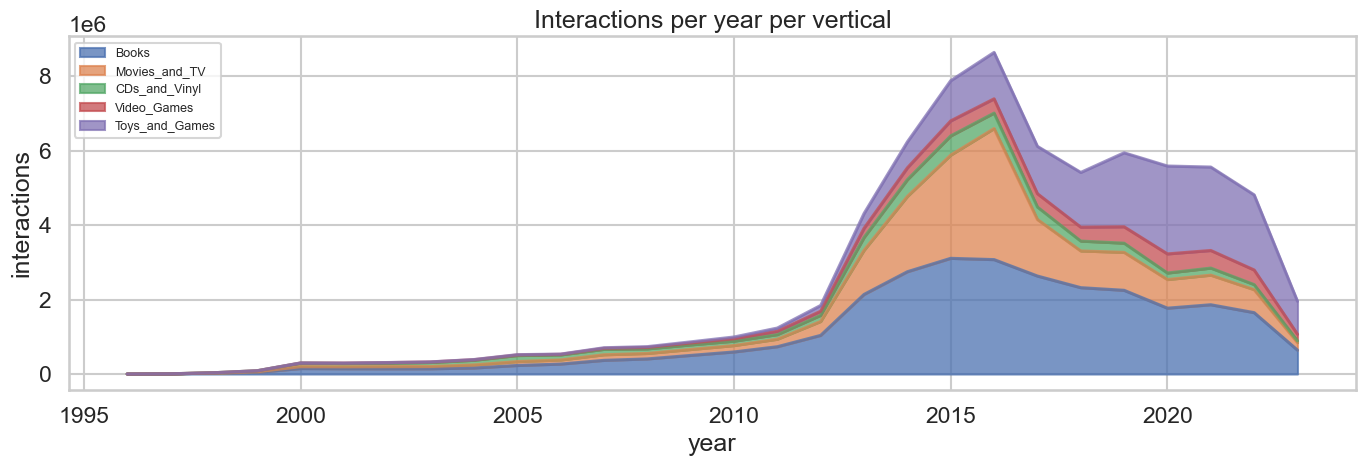

,Books,Movies_and_TV,CDs_and_Vinyl,Video_Games,Toys_and_Games
timestamp,,,,,
2012,1038267,374194,164550,110192,156386
2013,2138991,1186363,345722,245615,398375
2014,2749606,2024087,450958,318579,698062
2015,3109900,2775323,516675,403513,1080861
2016,3075673,3523601,415503,383870,1248517
2017,2633836,1520549,335189,358491,1272348
2018,2321039,986995,265503,374285,1472115
2019,2250129,1020009,246687,441337,1989546
2020,1769529,769727,175392,514523,2362745


In [6]:
# yearly volume per vertical — stacked bar
yearly = {}
for v in VERTICALS:
    s = pd.to_datetime(ratings[v]['timestamp'].astype('int64'), unit='ms').dt.year
    yearly[v] = s.value_counts().sort_index()
yearly_df = pd.DataFrame(yearly).fillna(0).astype(int)
yearly_df.plot(kind='area', figsize=(14, 5), alpha=0.75)
plt.title('Interactions per year per vertical')
plt.ylabel('interactions')
plt.xlabel('year')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()
yearly_df.tail(12)


### 2.2.4 Sparsity — items per user, users per item

Two distributions per vertical. Both are heavy-tailed in this corpus; we want
to see how heavy. Heavy fat-head means cold-start is harder than average,
because most users have very few interactions.


In [7]:
def quantile_table(s, qs=(0.5, 0.75, 0.9, 0.95, 0.99)):
    return {f'q{int(q*100)}': float(s.quantile(q)) for q in qs}

sparsity = []
for v in VERTICALS:
    df = ratings[v]
    iu = df.groupby('user_id').size()
    ui = df.groupby('parent_asin').size()
    row = {'vertical': v,
           'items_per_user_mean': iu.mean(),
           **{f'iu_{k}': v_ for k, v_ in quantile_table(iu).items()},
           'users_per_item_mean': ui.mean(),
           **{f'ui_{k}': v_ for k, v_ in quantile_table(ui).items()}}
    sparsity.append(row)
sparsity_df = pd.DataFrame(sparsity).set_index('vertical')
sparsity_df.round(2)


,items_per_user_mean,iu_q50,iu_q75,iu_q90,iu_q95,iu_q99,users_per_item_mean,ui_q50,ui_q75,ui_q90,ui_q95,ui_q99
vertical,,,,,,,,,,,,
Books,2.83,1.0,2.0,5.0,8.0,23.0,6.55,2.0,4.0,11.0,21.0,76.0
Movies_and_TV,2.64,1.0,2.0,5.0,8.0,21.0,22.95,3.0,9.0,35.0,78.0,322.0
CDs_and_Vinyl,2.72,1.0,2.0,5.0,8.0,24.0,6.80,2.0,4.0,12.0,24.0,91.0
Video_Games,1.65,1.0,2.0,3.0,4.0,9.0,33.19,4.0,14.0,50.0,116.0,537.0
Toys_and_Games,1.98,1.0,2.0,4.0,5.0,12.0,18.02,3.0,10.0,31.0,65.0,256.0


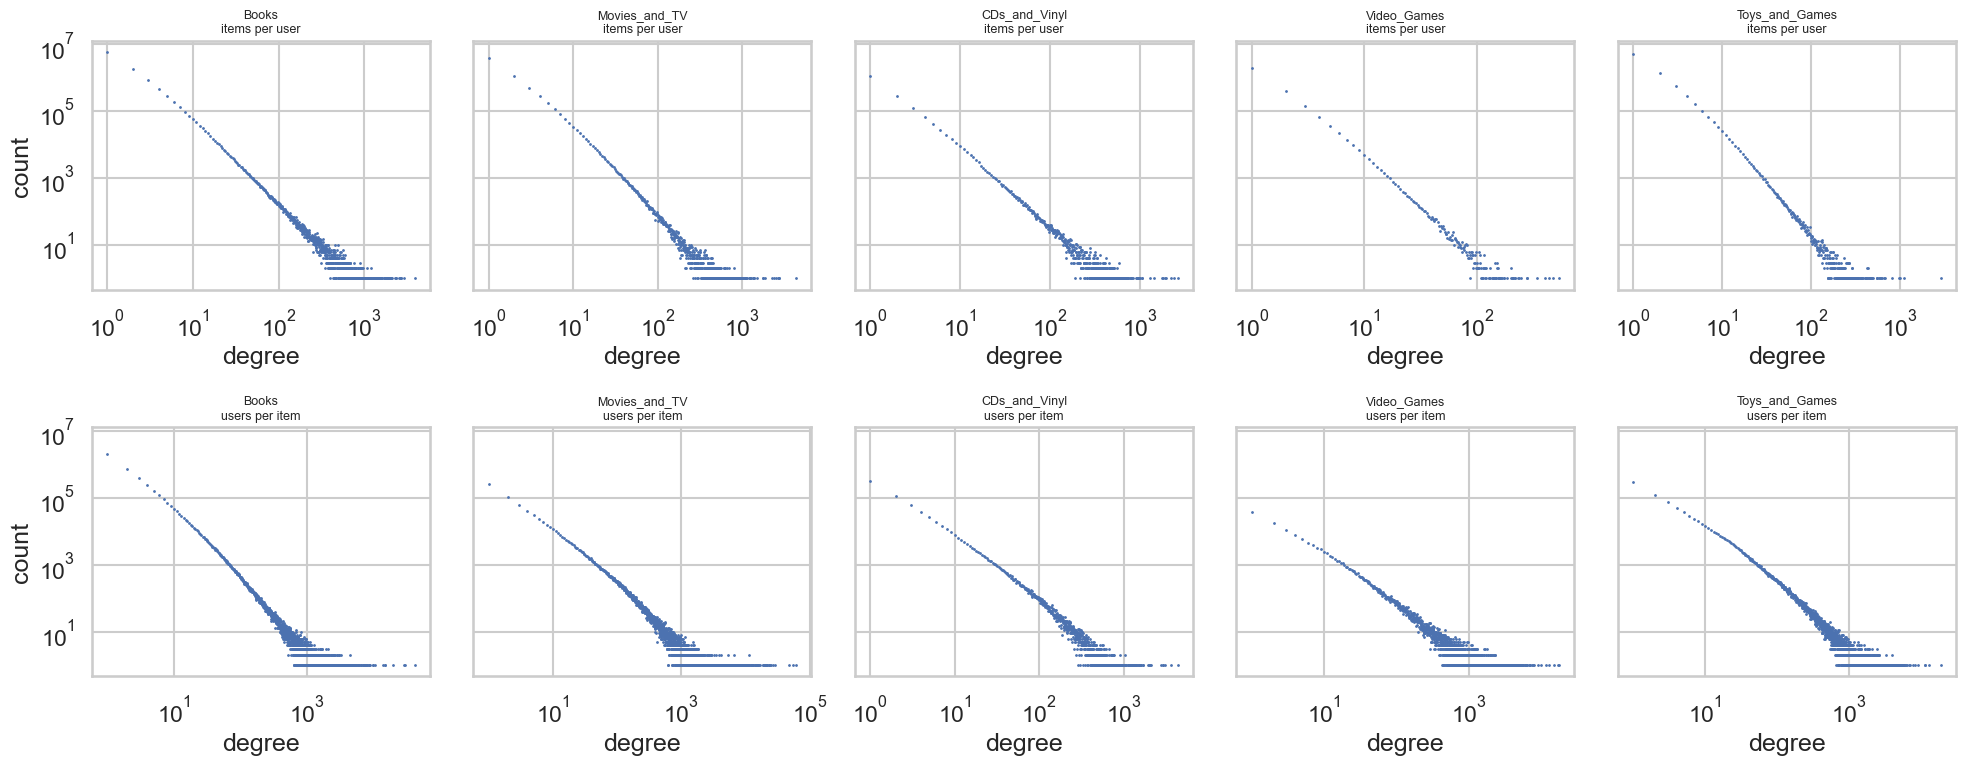

In [8]:
# log-log degree plots — items per user, users per item
fig, axes = plt.subplots(2, len(VERTICALS), figsize=(20, 8), sharey=True)
for j, v in enumerate(VERTICALS):
    df = ratings[v]
    iu = df.groupby('user_id').size()
    ui = df.groupby('parent_asin').size()
    for ax, s, label in [(axes[0, j], iu, 'items per user'),
                         (axes[1, j], ui, 'users per item')]:
        counts = s.value_counts().sort_index()
        ax.loglog(counts.index, counts.values, marker='.', linestyle='none', ms=2)
        ax.set_title(f'{v}\n{label}', fontsize=9)
        ax.set_xlabel('degree')
        if j == 0:
            ax.set_ylabel('count')
plt.tight_layout()
plt.show()


### 2.2.5 Metadata field population

For each meta file we stream once and compute, per record, whether the
high-importance fields are populated. "Populated" means:

- string fields (`title`): non-empty string after strip
- list fields (`description`, `features`, `categories`, `images`): non-empty list
- dict fields (`details`): non-empty dict
- numeric / nullable scalars (`price`, `average_rating`): not None

This pass also collects the category-tree depth and the title/description text
length distributions used in 2.2.6 below — done in one pass per file to keep
total runtime manageable on the 14 GB Books meta.


In [9]:
LIST_FIELDS = ['description', 'features', 'categories', 'images', 'videos']
STR_FIELDS = ['title', 'main_category', 'store']
DICT_FIELDS = ['details']
NUM_FIELDS = ['price', 'average_rating', 'rating_number']

def stream_meta_stats(path, sample_every=None):
    """One pass over a meta JSONL.

    Returns dict with:
      - n_items
      - non_null_rate per field
      - category_depths: Counter of len(categories)
      - title_lengths_kb: histogram of len(title) in chars
      - desc_chars: histogram of total description length in chars
    """
    n = 0
    populated = Counter()
    cat_depth = Counter()
    title_len_hist = Counter()
    desc_len_hist = Counter()
    feat_len_hist = Counter()
    main_cat = Counter()

    def bucket(x, edges):
        for i, e in enumerate(edges):
            if x <= e:
                return e
        return edges[-1] * 2  # overflow bucket

    title_edges = [0, 10, 25, 50, 100, 200, 400, 800]
    desc_edges = [0, 50, 200, 500, 1500, 5000, 20000]

    with open(path) as f:
        for line in tqdm(f, desc=path.name, unit=' rec'):
            n += 1
            if sample_every and n % sample_every:
                continue
            r = json.loads(line)
            # populated rate
            for k in STR_FIELDS:
                v = r.get(k)
                if isinstance(v, str) and v.strip():
                    populated[k] += 1
            for k in LIST_FIELDS:
                v = r.get(k)
                if isinstance(v, list) and len(v) > 0:
                    populated[k] += 1
            for k in DICT_FIELDS:
                v = r.get(k)
                if isinstance(v, dict) and len(v) > 0:
                    populated[k] += 1
            for k in NUM_FIELDS:
                if r.get(k) is not None:
                    populated[k] += 1
            # category depth + top-level category
            cats = r.get('categories') or []
            cat_depth[len(cats)] += 1
            if cats:
                main_cat[cats[0]] += 1
            # text lengths
            t = (r.get('title') or '').strip()
            title_len_hist[bucket(len(t), title_edges)] += 1
            d = r.get('description') or []
            d_len = sum(len(x) for x in d if isinstance(x, str))
            desc_len_hist[bucket(d_len, desc_edges)] += 1
            f_list = r.get('features') or []
            f_len = sum(len(x) for x in f_list if isinstance(x, str))
            feat_len_hist[bucket(f_len, desc_edges)] += 1
    return {
        'n_items': n,
        'populated': dict(populated),
        'cat_depth': dict(cat_depth),
        'main_cat_top': main_cat.most_common(15),
        'title_len_hist': dict(title_len_hist),
        'desc_len_hist': dict(desc_len_hist),
        'feat_len_hist': dict(feat_len_hist),
    }


In [10]:
# Stream all 5 meta files — this is the longest cell in the notebook.
# Books is ~14 GB; expect ~5–8 min total on a modern laptop.
meta_stats = {}
t0 = time.time()
for v in VERTICALS:
    t = time.time()
    meta_stats[v] = stream_meta_stats(meta_path(v))
    print(f'  done {v:18s} in {time.time()-t:5.1f}s  (n_items={meta_stats[v]["n_items"]:,})')
print(f'total: {time.time()-t0:.0f}s')


meta_Books.jsonl: 0 rec [00:00, ? rec/s]

  done Books              in  63.1s  (n_items=4,448,181)


meta_Movies_and_TV.jsonl: 0 rec [00:00, ? rec/s]

  done Movies_and_TV      in   7.4s  (n_items=748,224)


meta_CDs_and_Vinyl.jsonl: 0 rec [00:00, ? rec/s]

  done CDs_and_Vinyl      in   6.2s  (n_items=701,959)


meta_Video_Games.jsonl: 0 rec [00:00, ? rec/s]

  done Video_Games        in   2.0s  (n_items=137,269)


meta_Toys_and_Games.jsonl: 0 rec [00:00, ? rec/s]

  done Toys_and_Games     in  12.6s  (n_items=890,874)
total: 91s


In [11]:
# turn populated counts into rates and present as a per-field × per-vertical table
all_fields = STR_FIELDS + LIST_FIELDS + DICT_FIELDS + NUM_FIELDS
pop_rows = []
for v in VERTICALS:
    n = meta_stats[v]['n_items']
    pop = meta_stats[v]['populated']
    pop_rows.append({'vertical': v, **{f: pop.get(f, 0) / n for f in all_fields}})
pop_df = pd.DataFrame(pop_rows).set_index('vertical')
(pop_df * 100).round(1)


,title,main_category,store,description,features,categories,images,videos,details,price,average_rating,rating_number
vertical,,,,,,,,,,,,
Books,100.0,99.8,96.1,41.4,88.3,88.1,69.3,1.4,93.3,86.1,100.0,100.0
Movies_and_TV,58.0,95.1,52.5,46.5,5.0,57.9,100.0,2.8,98.6,35.3,100.0,100.0
CDs_and_Vinyl,100.0,99.9,99.9,64.9,0.2,100.0,100.0,0.6,96.6,78.7,100.0,100.0
Video_Games,100.0,92.0,96.8,62.3,71.2,90.8,99.9,21.1,97.5,45.2,100.0,100.0
Toys_and_Games,100.0,97.5,99.4,65.7,80.1,90.0,100.0,35.0,97.7,48.1,100.0,100.0


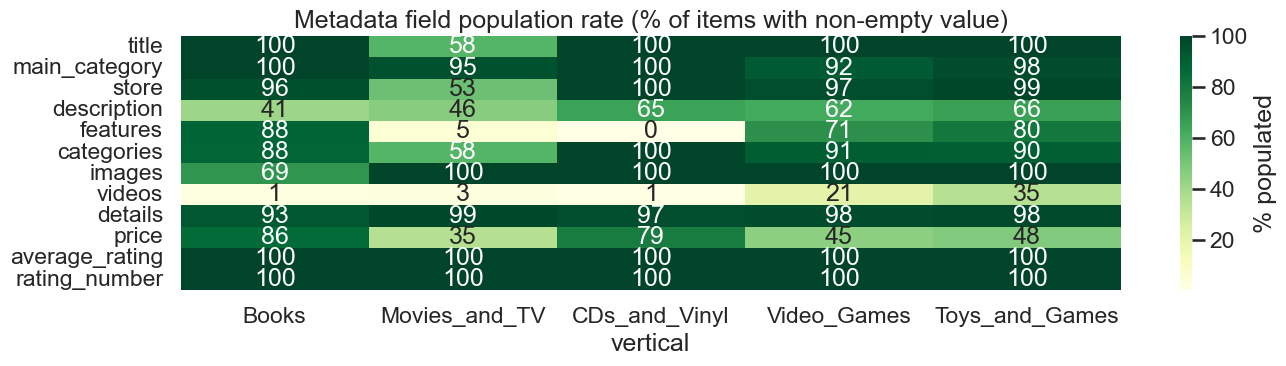

In [12]:
# heatmap of population rates
plt.figure(figsize=(14, 4))
sns.heatmap(pop_df.T * 100, annot=True, fmt='.0f', cmap='YlGn', cbar_kws={'label': '% populated'})
plt.title('Metadata field population rate (% of items with non-empty value)')
plt.tight_layout()
plt.show()


### 2.2.6 Category structure

Two views per vertical:
1. depth distribution — how deep are category paths?
2. top-level category — what does the root level actually look like?

This matters because the cross-vertical bridge uses categories as one of the
two transfer signals. Verticals with deeper, more-consistent trees give the
model more discriminative power.


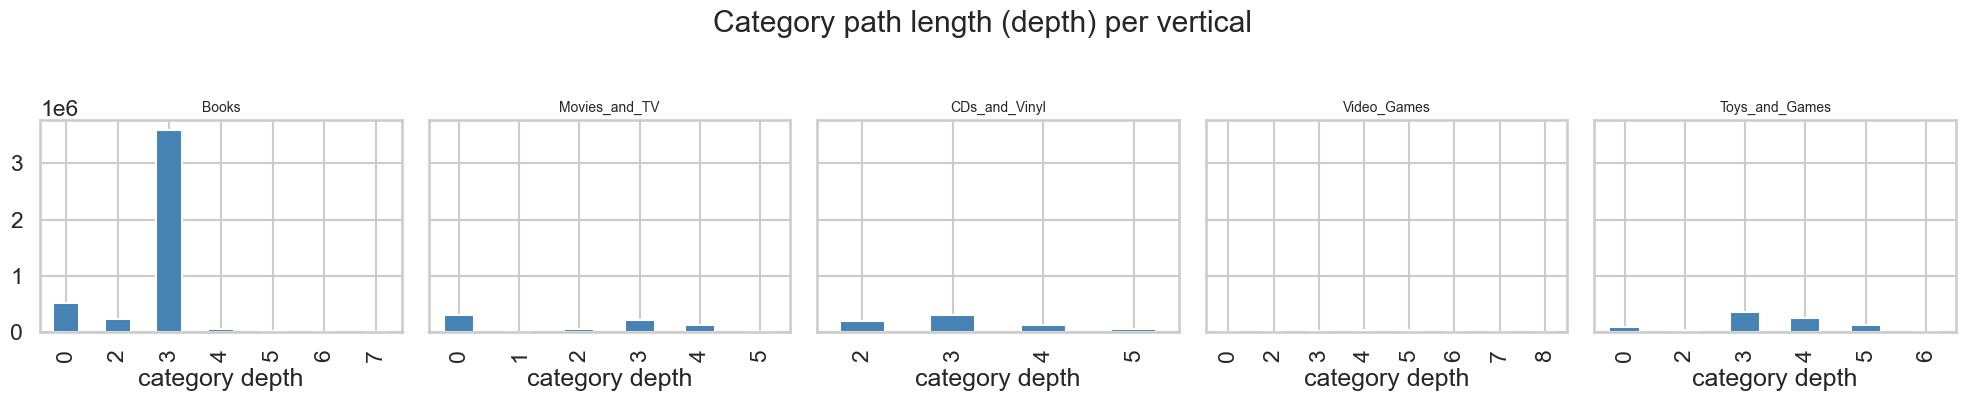

In [13]:
# category depth distribution per vertical
fig, axes = plt.subplots(1, len(VERTICALS), figsize=(20, 4), sharey=True)
for ax, v in zip(axes, VERTICALS):
    d = pd.Series(meta_stats[v]['cat_depth']).sort_index()
    d.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(v, fontsize=10)
    ax.set_xlabel('category depth')
plt.suptitle('Category path length (depth) per vertical', y=1.02)
plt.tight_layout()
plt.show()


In [14]:
# top-level category per vertical — sanity-check what 'main_category' looks like
for v in VERTICALS:
    print(f'\n== {v} ==')
    for cat, c in meta_stats[v]['main_cat_top'][:10]:
        print(f'  {c:>10,d}  {cat}')



== Books ==
   3,907,065  Books
      12,443  Audible Books & Originals

== Movies_and_TV ==
     398,401  Movies & TV
       7,043  Comedy
       5,771  Drama
       5,155  Suspense
       3,847  Documentary
       2,638  Science Fiction
       2,032  Unscripted
       1,638  Special Interest
         949  Horror
         848  Animation

== CDs_and_Vinyl ==
     701,959  CDs & Vinyl

== Video_Games ==
     124,619  Video Games
          13  Purchase Circles

== Toys_and_Games ==
     786,938  Toys & Games
      10,737  Remote & App Controlled Vehicles & Parts
       4,247  Remote & App Controlled Vehicle Parts


### 2.2.7 Text length distributions

Item-side text feeds the MiniLM encoder. Long-tail items with empty
title/description force the encoder to fall back on whatever is left. Here we
quantify how much text we actually have to embed per vertical.


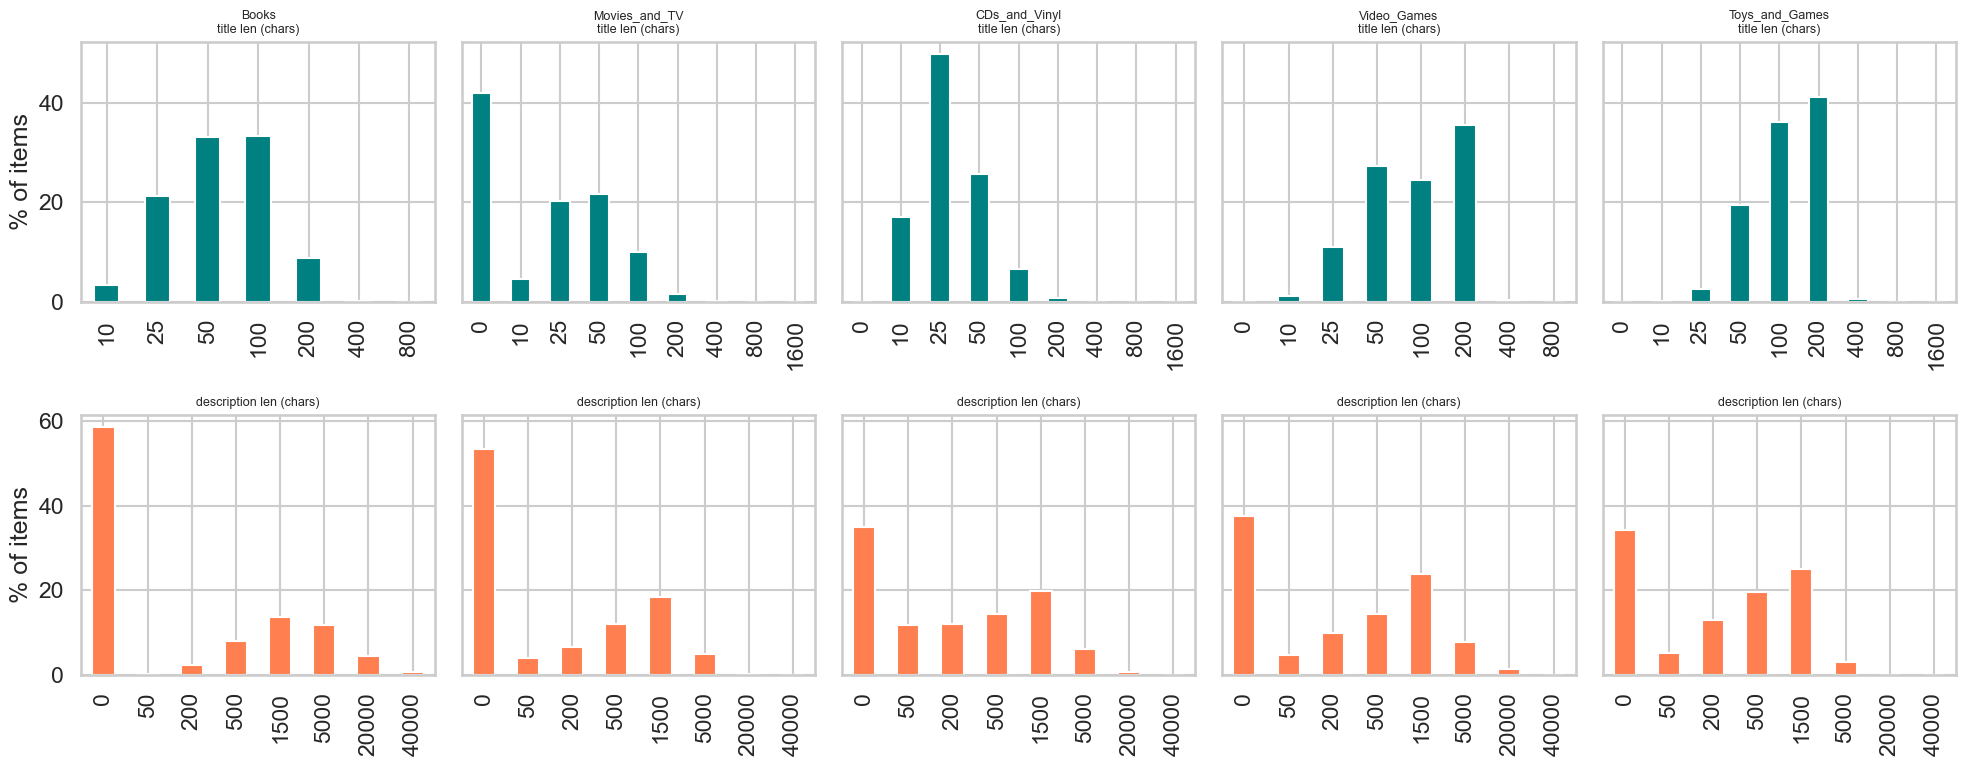

In [15]:
def hist_to_df(hist_dict):
    return pd.Series(hist_dict).sort_index()

fig, axes = plt.subplots(2, len(VERTICALS), figsize=(20, 8), sharey='row')
for j, v in enumerate(VERTICALS):
    n = meta_stats[v]['n_items']
    h_title = hist_to_df(meta_stats[v]['title_len_hist'])
    h_desc = hist_to_df(meta_stats[v]['desc_len_hist'])
    (h_title / n * 100).plot(kind='bar', ax=axes[0, j], color='teal')
    axes[0, j].set_title(f'{v}\ntitle len (chars)', fontsize=9)
    (h_desc / n * 100).plot(kind='bar', ax=axes[1, j], color='coral')
    axes[1, j].set_title(f'description len (chars)', fontsize=9)
    for ax in (axes[0, j], axes[1, j]):
        ax.set_ylabel('% of items')
plt.tight_layout()
plt.show()


### 2.2.8 Keys — ratings ⨝ meta within a vertical

CRISP-DM §2.2 calls for explicit checking of key overlaps across tables. The
join key is `parent_asin`. We want to know, per vertical, the rate of
**orphan interactions** — interactions whose ASIN has no metadata record —
because orphans cannot be embedded by the §S3 feature pipeline.


In [16]:
# build per-vertical set of meta ASINs by streaming meta files (lighter pass — only parent_asin)
meta_asins = {}
for v in VERTICALS:
    asins = set()
    with open(meta_path(v)) as f:
        for line in tqdm(f, desc=f'asins {v}', unit=' rec'):
            r = json.loads(line)
            a = r.get('parent_asin')
            if a:
                asins.add(a)
    meta_asins[v] = asins
    print(f'  {v:18s} meta asins = {len(asins):,}')


asins Books: 0 rec [00:00, ? rec/s]

  Books              meta asins = 4,448,181


asins Movies_and_TV: 0 rec [00:00, ? rec/s]

  Movies_and_TV      meta asins = 748,224


asins CDs_and_Vinyl: 0 rec [00:00, ? rec/s]

  CDs_and_Vinyl      meta asins = 701,959


asins Video_Games: 0 rec [00:00, ? rec/s]

  Video_Games        meta asins = 137,269


asins Toys_and_Games: 0 rec [00:00, ? rec/s]

  Toys_and_Games     meta asins = 890,874


In [17]:
join_rows = []
for v in VERTICALS:
    df = ratings[v]
    asins_in_ratings = set(df['parent_asin'].astype(str).unique())
    have_meta = asins_in_ratings & meta_asins[v]
    orphan_asins = asins_in_ratings - meta_asins[v]
    n_orphan_interactions = int(df['parent_asin'].isin(orphan_asins).sum())
    join_rows.append({
        'vertical': v,
        'asins_in_ratings': len(asins_in_ratings),
        'asins_with_meta': len(have_meta),
        'orphan_asins': len(orphan_asins),
        'orphan_asin_pct': len(orphan_asins) / max(1, len(asins_in_ratings)) * 100,
        'orphan_interactions': n_orphan_interactions,
        'orphan_interaction_pct': n_orphan_interactions / len(df) * 100,
    })
join_df = pd.DataFrame(join_rows).set_index('vertical')
join_df.round(2)


,asins_in_ratings,asins_with_meta,orphan_asins,orphan_asin_pct,orphan_interactions,orphan_interaction_pct
vertical,,,,,,
Books,4446065,4446065,0,0.0,0,0.0
Movies_and_TV,747764,747764,0,0.0,0,0.0
CDs_and_Vinyl,701673,701673,0,0.0,0,0.0
Video_Games,137249,137249,0,0.0,0,0.0
Toys_and_Games,890667,890667,0,0.0,0,0.0


## §2.3 Explore Data

### 2.3.1 Pairwise user overlap — 0-core

This is the single most important EDA output for the project: how many users
appear in both of any two verticals? The chosen source→target pair has to
clear the §S2 threshold (~10k shared users) for the EMCDR mapping function to
be trainable.

We compute overlap at the **0-core** level first (no filtering), and again
after applying 5-core in 2.3.2. The 5-core pass typically halves the overlap
or worse, so the 0-core number is an upper bound.


In [18]:
# build per-vertical user sets once
user_sets_0core = {v: set(ratings[v]['user_id'].astype(str).unique()) for v in VERTICALS}
for v in VERTICALS:
    print(f'  {v:18s} users (0-core) = {len(user_sets_0core[v]):,}')


  Books              users (0-core) = 10,297,355
  Movies_and_TV      users (0-core) = 6,503,429
  CDs_and_Vinyl      users (0-core) = 1,754,118
  Video_Games        users (0-core) = 2,766,656
  Toys_and_Games     users (0-core) = 8,116,226


In [19]:
def overlap_matrix(user_sets, verticals):
    n = len(verticals)
    M = np.zeros((n, n), dtype=int)
    for i, a in enumerate(verticals):
        for j, b in enumerate(verticals):
            if i == j:
                M[i, j] = len(user_sets[a])
            else:
                M[i, j] = len(user_sets[a] & user_sets[b])
    return pd.DataFrame(M, index=verticals, columns=verticals)

ov0 = overlap_matrix(user_sets_0core, VERTICALS)
print('0-core pairwise overlap (diagonal = total users in vertical):')
ov0


0-core pairwise overlap (diagonal = total users in vertical):


,Books,Movies_and_TV,CDs_and_Vinyl,Video_Games,Toys_and_Games
Books,10297355,2531146,877324,783876,2560458
Movies_and_TV,2531146,6503429,713375,674122,1612938
CDs_and_Vinyl,877324,713375,1754118,198885,444157
Video_Games,783876,674122,198885,2766656,860026
Toys_and_Games,2560458,1612938,444157,860026,8116226


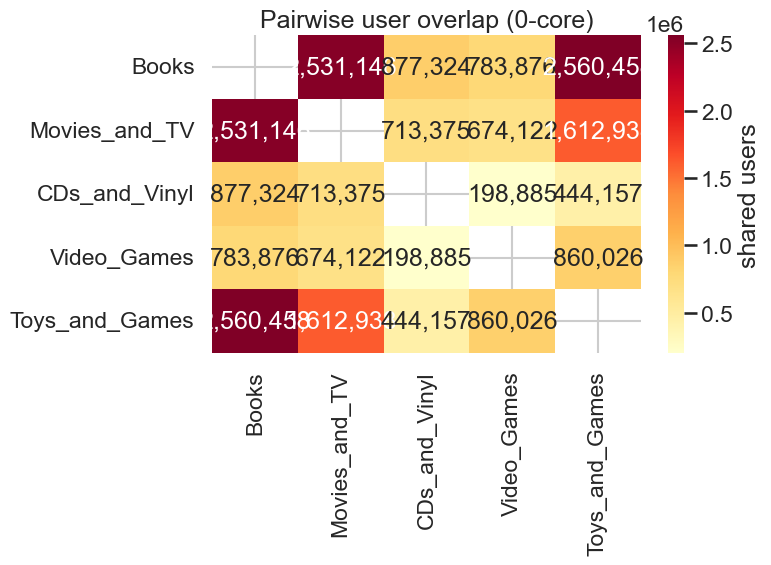

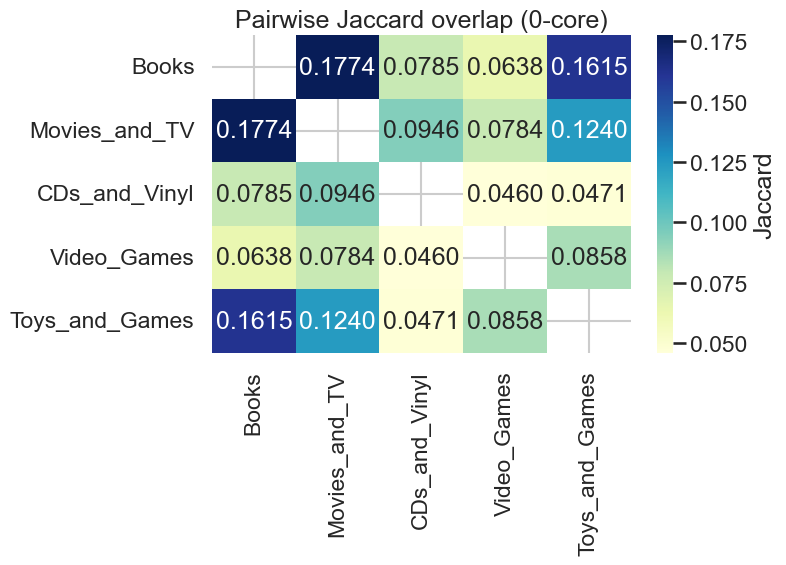

In [20]:
# heatmap, masking diagonal so it doesn't dominate the colour scale
mask = np.eye(len(VERTICALS), dtype=bool)
plt.figure(figsize=(8, 6))
sns.heatmap(ov0, annot=True, fmt=',d', mask=mask, cmap='YlOrRd', cbar_kws={'label': 'shared users'})
plt.title('Pairwise user overlap (0-core)')
plt.tight_layout()
plt.show()

# also show as Jaccard
def jaccard_matrix(user_sets, verticals):
    n = len(verticals)
    M = np.zeros((n, n))
    for i, a in enumerate(verticals):
        for j, b in enumerate(verticals):
            if i == j:
                M[i, j] = 1.0
            else:
                inter = len(user_sets[a] & user_sets[b])
                union = len(user_sets[a] | user_sets[b])
                M[i, j] = inter / union if union else 0
    return pd.DataFrame(M, index=verticals, columns=verticals)

jac0 = jaccard_matrix(user_sets_0core, VERTICALS)
plt.figure(figsize=(8, 6))
sns.heatmap(jac0, annot=True, fmt='.4f', mask=mask, cmap='YlGnBu', cbar_kws={'label': 'Jaccard'})
plt.title('Pairwise Jaccard overlap (0-core)')
plt.tight_layout()
plt.show()


### 2.3.2 5-core filter and recount

5-core = iteratively drop users with <5 interactions and items with <5
interactions until the table is stable. Standard density filter for
recommendation benchmarks. Done per-vertical independently.


In [21]:
def kcore_filter(df, k=5, max_iters=30):
    """Iterative k-core on (user_id, parent_asin) interactions."""
    prev_size = -1
    for it in range(max_iters):
        u_counts = df.groupby('user_id').size()
        keep_u = u_counts[u_counts >= k].index
        df = df[df['user_id'].isin(keep_u)]
        i_counts = df.groupby('parent_asin').size()
        keep_i = i_counts[i_counts >= k].index
        df = df[df['parent_asin'].isin(keep_i)]
        if len(df) == prev_size:
            return df, it + 1
        prev_size = len(df)
    return df, max_iters

ratings_5c = {}
for v in VERTICALS:
    t = time.time()
    df5, iters = kcore_filter(ratings[v], k=5)
    ratings_5c[v] = df5
    print(f'  {v:18s} 0-core={len(ratings[v]):>11,d}  5-core={len(df5):>11,d}  '
          f'kept={len(df5)/len(ratings[v]):.1%}  iters={iters}  ({time.time()-t:.1f}s)')


  Books              0-core= 29,139,329  5-core=  9,488,297  kept=32.6%  iters=10  (40.1s)


  Movies_and_TV      0-core= 17,158,519  5-core=  7,441,129  kept=43.4%  iters=7  (17.4s)


  CDs_and_Vinyl      0-core=  4,772,071  5-core=  1,552,764  kept=32.5%  iters=10  (4.3s)


  Video_Games        0-core=  4,555,500  5-core=    814,586  kept=17.9%  iters=7  (2.9s)


  Toys_and_Games     0-core= 16,052,440  5-core=  3,861,886  kept=24.1%  iters=9  (16.4s)


In [22]:
# 5-core summary table
rows = []
for v in VERTICALS:
    r0, r5 = ratings[v], ratings_5c[v]
    rows.append({
        'vertical': v,
        'inter_0core': len(r0),
        'inter_5core': len(r5),
        'inter_kept_%': len(r5) / len(r0) * 100,
        'users_0core': r0['user_id'].nunique(),
        'users_5core': r5['user_id'].nunique(),
        'items_0core': r0['parent_asin'].nunique(),
        'items_5core': r5['parent_asin'].nunique(),
    })
core_df = pd.DataFrame(rows).set_index('vertical')
core_df.round(1)


,inter_0core,inter_5core,inter_kept_%,users_0core,users_5core,items_0core,items_5core
vertical,,,,,,,
Books,29139329,9488297,32.6,10297355,776370,4446065,495063
Movies_and_TV,17158519,7441129,43.4,6503429,657203,747764,197943
CDs_and_Vinyl,4772071,1552764,32.5,1754118,123876,701673,89370
Video_Games,4555500,814586,17.9,2766656,94762,137249,25612
Toys_and_Games,16052440,3861886,24.1,8116226,432264,890667,162035


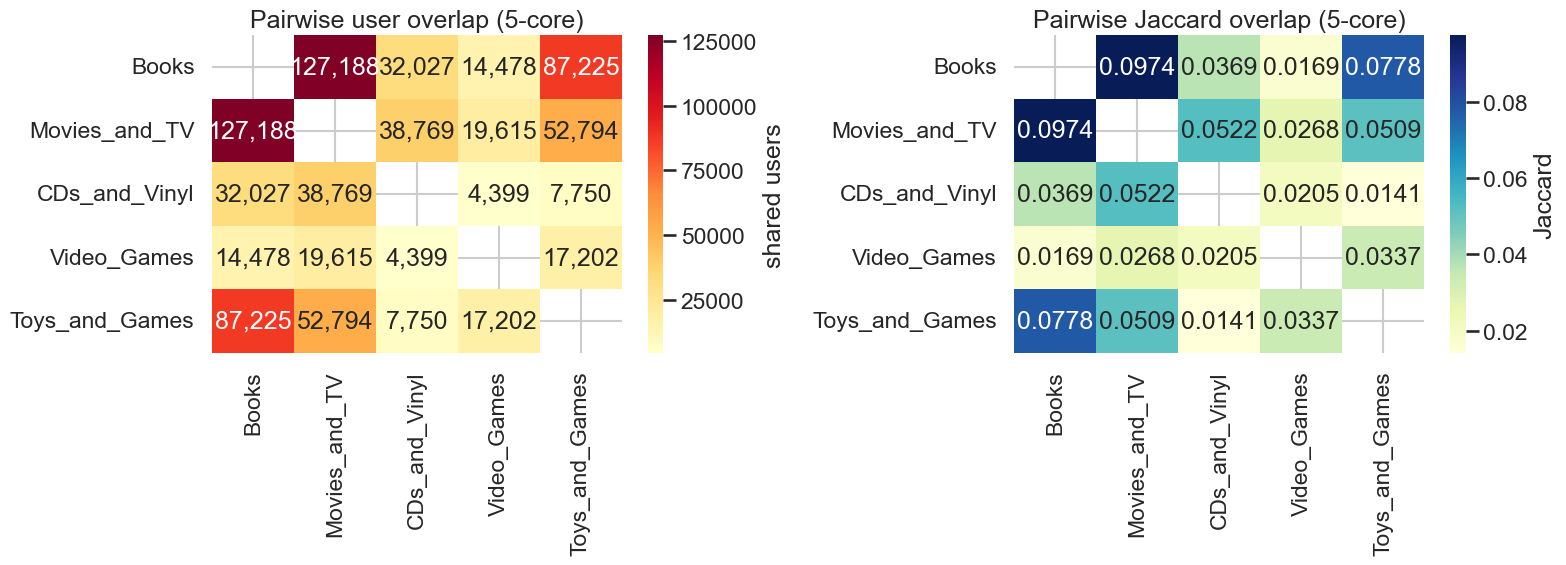

,Books,Movies_and_TV,CDs_and_Vinyl,Video_Games,Toys_and_Games
Books,776370,127188,32027,14478,87225
Movies_and_TV,127188,657203,38769,19615,52794
CDs_and_Vinyl,32027,38769,123876,4399,7750
Video_Games,14478,19615,4399,94762,17202
Toys_and_Games,87225,52794,7750,17202,432264


In [23]:
# pairwise overlap after 5-core
user_sets_5core = {v: set(ratings_5c[v]['user_id'].astype(str).unique()) for v in VERTICALS}
ov5 = overlap_matrix(user_sets_5core, VERTICALS)
jac5 = jaccard_matrix(user_sets_5core, VERTICALS)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(ov5, annot=True, fmt=',d', mask=mask, cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'shared users'})
axes[0].set_title('Pairwise user overlap (5-core)')
sns.heatmap(jac5, annot=True, fmt='.4f', mask=mask, cmap='YlGnBu', ax=axes[1],
            cbar_kws={'label': 'Jaccard'})
axes[1].set_title('Pairwise Jaccard overlap (5-core)')
plt.tight_layout()
plt.show()
ov5


### 2.3.3 Source → target pair pick

The pair we lock for the EMCDR experiment must satisfy:

1. **Overlap floor**: shared users ≥ ~10k after 5-core (HW1 §S2). This is the
   gating check — if no pair clears it, the R1 contingency (relax to 3-core
   or swap verticals) kicks in.
2. **Catalog richness**: both verticals have populated `title` / `description`
   / `categories` on most items (≥ 80–90% from 2.2.5). Categories-only and
   text-only ablations both need real content.
3. **Asymmetric source-richness**: the source vertical should be the *larger*
   of the two, so the user-side history feeding the mapping function is dense.
   Books is almost certainly the source for any pair containing it.

Rank candidate pairs.


In [24]:
# enumerate all 10 unordered pairs with overlap, richness, and pick the best
def field_rate(stats, v, f):
    return stats[v]['populated'].get(f, 0) / stats[v]['n_items']

pair_rows = []
for a, b in combinations(VERTICALS, 2):
    shared_5c = len(user_sets_5core[a] & user_sets_5core[b])
    # source is the larger vertical
    src, tgt = (a, b) if len(user_sets_5core[a]) >= len(user_sets_5core[b]) else (b, a)
    # average key-field population for both members
    rich = np.mean([field_rate(meta_stats, x, f) for x in (a, b)
                    for f in ('title', 'description', 'categories')])
    pair_rows.append({
        'source': src, 'target': tgt,
        'shared_users_5c': shared_5c,
        'clears_floor_10k': shared_5c >= 10_000,
        'src_users_5c': len(user_sets_5core[src]),
        'tgt_users_5c': len(user_sets_5core[tgt]),
        'avg_richness': rich,
    })
pair_df = pd.DataFrame(pair_rows).sort_values('shared_users_5c', ascending=False).reset_index(drop=True)
pair_df.round(3)


,source,target,shared_users_5c,clears_floor_10k,src_users_5c,tgt_users_5c,avg_richness
0,Books,Movies_and_TV,127188,True,776370,657203,0.653
1,Books,Toys_and_Games,87225,True,776370,432264,0.809
2,Movies_and_TV,Toys_and_Games,52794,True,657203,432264,0.697
3,Movies_and_TV,CDs_and_Vinyl,38769,True,657203,123876,0.712
4,Books,CDs_and_Vinyl,32027,True,776370,123876,0.824
5,Movies_and_TV,Video_Games,19615,True,657203,94762,0.693
6,Toys_and_Games,Video_Games,17202,True,432264,94762,0.848
7,Books,Video_Games,14478,True,776370,94762,0.804
8,Toys_and_Games,CDs_and_Vinyl,7750,False,432264,123876,0.868
9,CDs_and_Vinyl,Video_Games,4399,False,123876,94762,0.863


**Reading the table:**

- The first row is the most-promising pair on raw overlap.
- `clears_floor_10k = True` rows are viable; `False` rows trigger the
  R1 contingency.
- Ties on overlap break on `avg_richness` — pick the pair where item-side
  text is most populated for both members.
- If Books appears in the top pair, it is the source (it is the largest and
  most metadata-rich vertical).

Final pick is locked here and feeds §3.1 (Select Data).


## §2.4 Verify Data Quality

Quality checks that the §2.2/§2.3 passes did not already cover: duplicate
interactions, rating-value sanity, null keys, and timestamp integrity. The two
completeness results §2.4 also needs — orphan interactions (`join_df`, §2.2.8) and
the missing-value inventory (`pop_df`, §2.2.5) — were produced above and feed
straight into this section.

In [ ]:
# Per-vertical quality checks on the 0-core ratings tables.
quality = []
for v in VERTICALS:
    df = ratings[v]
    ts = df['timestamp'].astype('int64')
    quality.append({
        'vertical': v,
        'rows': len(df),
        'dup_interactions': int(df.duplicated(subset=['user_id', 'parent_asin']).sum()),
        'rating_out_of_range': int((~df['rating'].astype('int64').isin([1, 2, 3, 4, 5])).sum()),
        'null_keys': int((df['user_id'].isna() | df['parent_asin'].isna()).sum()),
        'nonpositive_ts': int((ts <= 0).sum()),
        'ts_min': pd.to_datetime(ts.min(), unit='ms'),
        'ts_max': pd.to_datetime(ts.max(), unit='ms'),
    })
quality_df = pd.DataFrame(quality).set_index('vertical')
quality_df

**Findings (computed over the full snapshot).** Every vertical has **zero duplicate
(user, item) interactions**, **no null keys**, and **no non-positive timestamps**; all
timestamps fall between 1996 and September 2023. Ratings are integer-valued in 1–5
everywhere **except four rows in Books that carry a rating of 0**. Together with the
**zero orphan interactions** from §2.2.8 and the field-population rates from §2.2.5,
the only corrective actions needed are: drop the four Books zero-ratings, drop the
universally-null `bought_together` field, and apply the `title`/`store`/`details`
fallback for items whose rich-text fields are empty. No de-duplication, key repair,
or timestamp cleaning is required.

---

## Hand-off to §2.4 (Verify Data Quality) and §3 (Data Preparation)

What this notebook produces that the next phases consume:

- `volumetric_df` and `core_df` → §2.2 write-up.
- `ts_df`, `yearly_df` → §2.2 + decision on time-based split feasibility.
- `pop_df` → §2.4 (missing-data inventory) and §2.2 attribute-quality table.
- `join_df` → §2.4 (orphan interactions) and §3.2 (cleaning policy for
  metadata-less ASINs).
- `pair_df` → §3.1 (the source→target pair selection).
- `ratings_5c[<source>]` and `ratings_5c[<target>]` → §3.x as the modeling
  input snapshot.
